This Jupyter notebook uses wordcloud and matplotlib to build the visualizations. It joins the ksp_factors table to the unit_code lookup table to display readable descriptions of the factors that may have caused or influenced an incident.

In [1]:
import os
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import sqlite3

In [2]:
# Ingest data from unit factor table into dataframe

# Define the path for the SQLite database
cwd = os.getcwd()
database_path = f'{cwd}/data/crash_data.db'

# Connect to the database
conn = sqlite3.connect(f'{cwd}/data/crash_data.db')


# Execute SQL query and load results into a DataFrame
query = """
SELECT t1.Factor, t2.Description
FROM ksp_factors t1
JOIN unit_factor_code_lut t2
    ON t1.Factor = t2.Factor_Code
"""
df = pd.read_sql_query(query, conn)

# Close the database connection
conn.close()

The data from the query above is combined into a single text string to be displayed in the workcloud visualization.

In [3]:
# Combine all descriptions into a single string
text = " ".join(df['Description'].tolist())

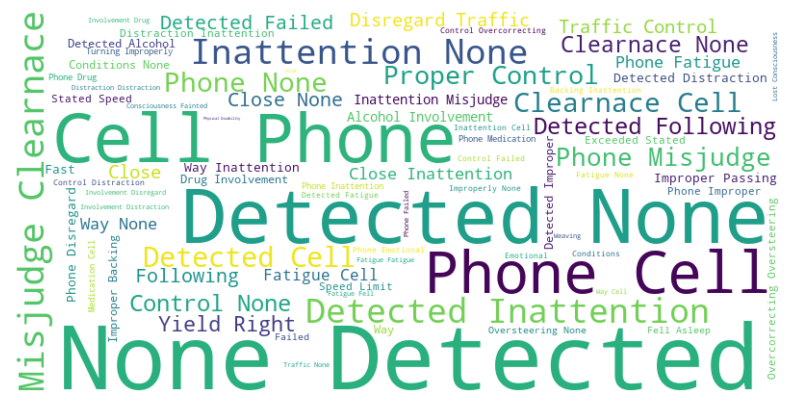

In [4]:
# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Data was then added to calculate the frequency of each factor description.  Using the top 10 factors, a bar graph is generated to show the counts recorded for each factor.

In [5]:
# Calculate the frequency of each factor description
factor_counts = df['Description'].value_counts()

In [6]:
# Identify the top 10 most common factors
top_10_factors = factor_counts.head(10)

In [7]:
# Calculate the total number of records
total_records = len(df)

# Calculate the percentage of records for the top 5 factors
top_10_percentages = (top_10_factors / total_records) * 100

# Round the percentages to two decimal places
top_10_percentages = top_10_percentages.round(2)

# Combine the factor names and their percentages into a DataFrame
top_10_factors_df = pd.DataFrame({
    'Factor': top_10_factors.index,
    'Count': top_10_factors.values,
    'Percentage': top_10_percentages.values
})

# Display the DataFrame
print(top_10_factors_df)

                         Factor  Count  Percentage
0                 None Detected  12995       48.12
1                    Cell Phone   7161       26.52
2                   Inattention   1737        6.43
3            Misjudge Clearnace   1244        4.61
4           Following Too Close    790        2.93
5      Not Under Proper Control    597        2.21
6                         Other    449        1.66
7  Failed to Yield Right of Way    398        1.47
8     Disregard Traffic Control    256        0.95
9                       Fatigue    250        0.93


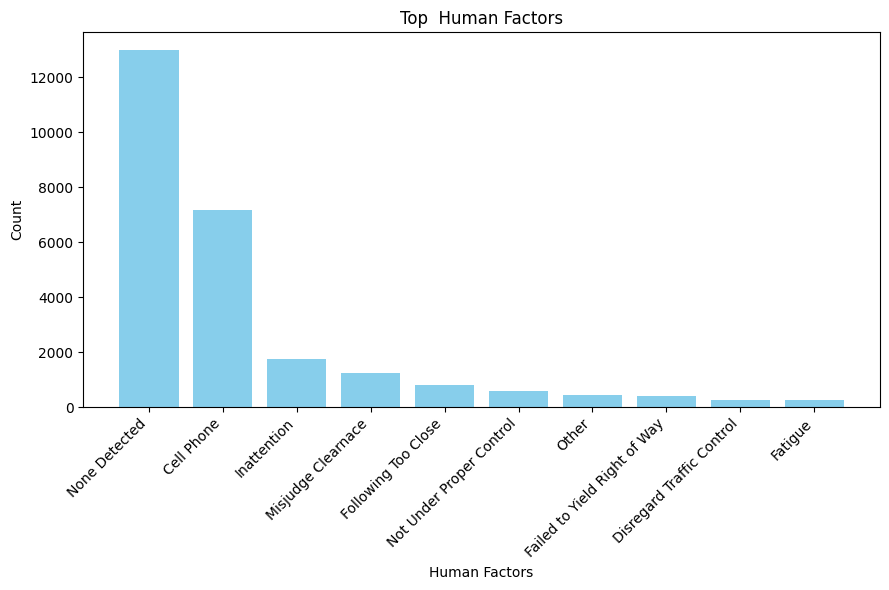

In [8]:
# Bar chart
plt.figure(figsize=(9, 6))
plt.bar(top_10_factors_df['Factor'], top_10_factors_df['Count'], color='skyblue')
plt.xlabel('Human Factors')
plt.ylabel('Count')
plt.title('Top  Human Factors')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Converting the counts to percentages, the factor names and their percentages are displayed as a pie chart visualization.

In [9]:
# Define a function to format the autopct text
def autopct_format(pct):
    return f'{pct:.2f}%'

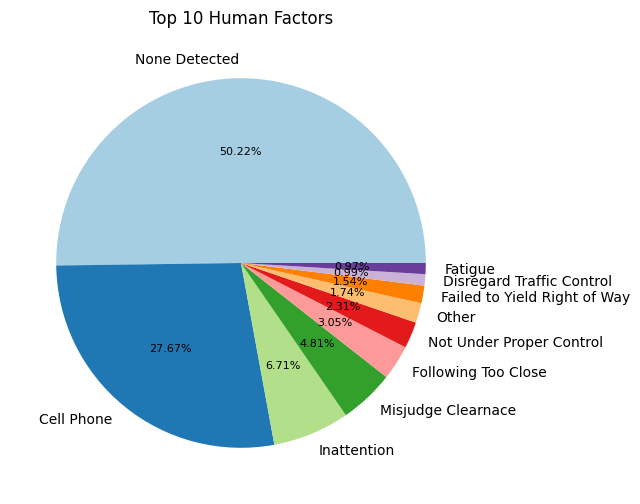

In [10]:
# Pie chart with smaller font for percent values
plt.figure(figsize=(9, 6))
wedges, texts, autotexts = plt.pie(top_10_factors_df['Count'], labels=top_10_factors_df['Factor'], autopct=autopct_format, colors=plt.cm.Paired.colors)

# Set the font size for the percent values
for autotext in autotexts:
    autotext.set_fontsize(8)

plt.title('Top 10 Human Factors')
plt.show()